- Procedencia de los viajeros por años del 2015 al 2019

In [3]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [4]:

# ── 1. CARGA DE ARCHIVOS ──────────────────────────────────────────────────────

ruta = "../../data/viajeros_*.csv"
files = glob.glob(ruta)
df_list = []

for file in sorted(files):
    nombre = os.path.basename(file)
    anyo = nombre.split("_")[1].replace(".csv", "")
    
    with open(file, encoding="latin1") as f:
        primera_linea = f.readline()
    sep = "\t" if "\t" in primera_linea else ";"
    
    df = pd.read_csv(file, sep=sep, encoding="latin1")
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')
    df["Año"] = anyo
    df_list.append(df)

df_total = pd.concat(df_list, ignore_index=True)

In [5]:
# ── 2. LIMPIEZA DE LA COLUMNA TOTAL ──────────────────────────────────────────

df_total["Total"] = (
    df_total["Total"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .replace("", "0")
    .pipe(pd.to_numeric, errors="coerce")
)

In [6]:
# ── 3. AGREGACIÓN ANUAL (sumando meses, excluyendo fila "Total") ──────────────

df_anual = (
    df_total[df_total["Meses"] != "Total"]
    .groupby(["Año", "País de residencia"], as_index=False)["Total"]
    .sum()
)


In [7]:
# ── 4. TOP N PAÍSES POR AÑO  ───────────────────────

excluir = ["Total", "Residentes en España", "No residentes en España",
           "Unión Europea 27 (sin España)", "Países africanos",
           "Resto del mundo"]

top_n = 10

procedencia_limpia = (
    df_anual[~df_anual["País de residencia"].isin(excluir)]
    .sort_values(["Año", "Total"], ascending=[True, False])
    .groupby("Año")
    .head(top_n)
    .reset_index(drop=True)
)

display(procedencia_limpia)

,Año,País de residencia,Total
0,2015,Reino Unido,6252363
1,2015,Alemania,4967853
2,2015,Francia,3982573
3,2015,Italia,2003159
4,2015,Estados Unidos,1899110
5,2015,Países Bajos,1199899
6,2015,Bélgica,900671
7,2015,Portugal,727483
8,2015,Suiza,670620
9,2015,Rusia,638953


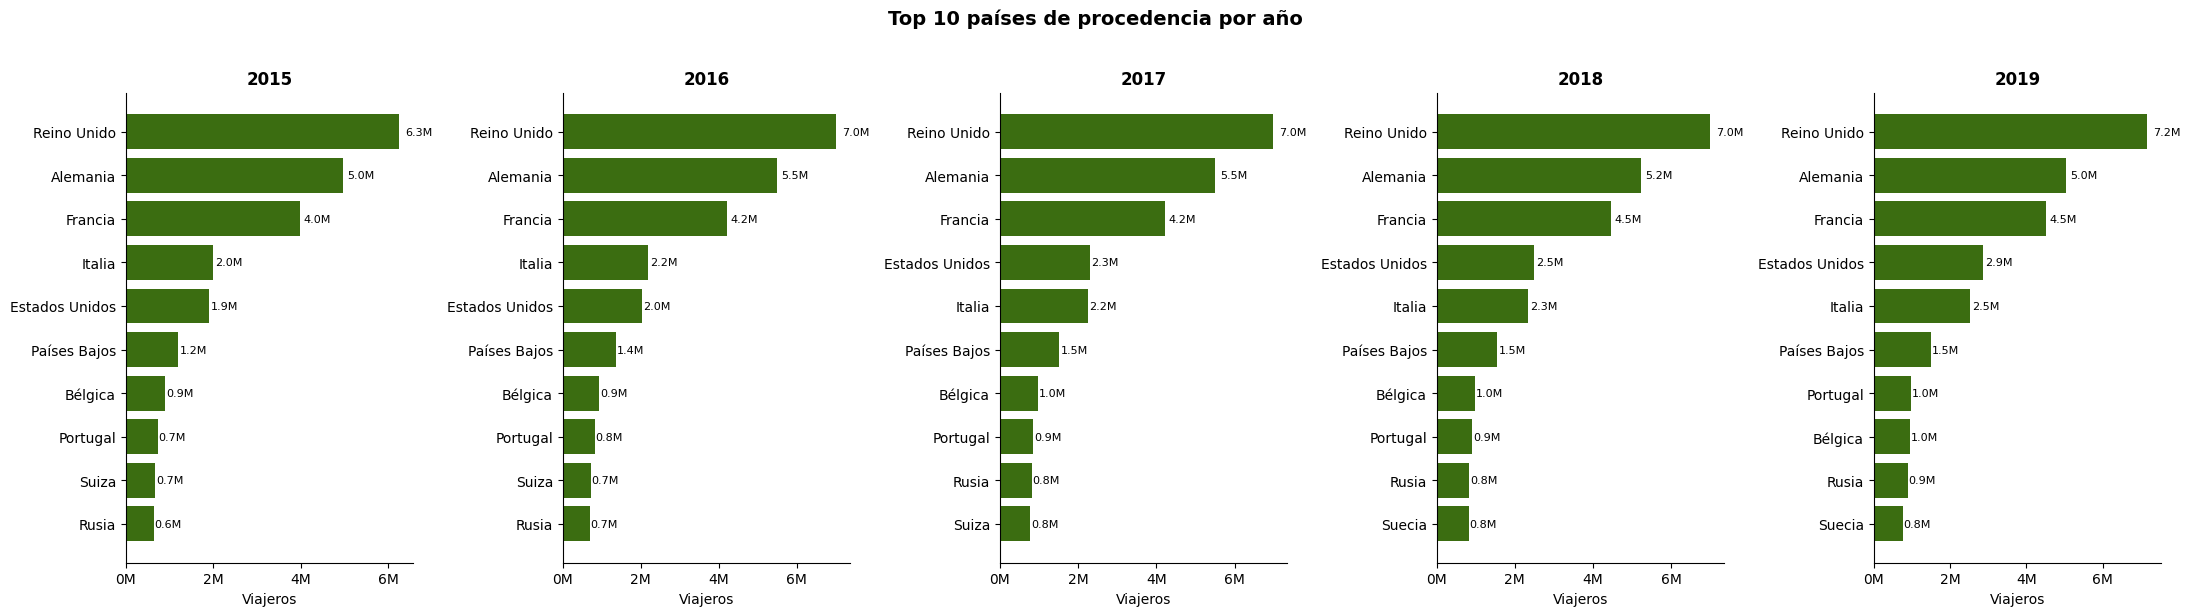

In [8]:


# ── 5. VISUALIZACIÓN ──────────────────────────────────────────────────────────

años = sorted(procedencia_limpia["Año"].unique())
fig, axes = plt.subplots(1, len(años), figsize=(22, 6), sharey=False)

for ax, anyo in zip(axes, años):
    datos = (
        procedencia_limpia[procedencia_limpia["Año"] == anyo]
        .sort_values("Total", ascending=True)
    )
    
    bars = ax.barh(datos["País de residencia"], datos["Total"], color="#3B6D11")
    
    for bar, val in zip(bars, datos["Total"]):
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                f"{val/1e6:.1f}M", va="center", fontsize=8)
    
    ax.set_title(anyo, fontweight="bold", fontsize=12)
    ax.set_xlabel("Viajeros")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    ax.spines[["top", "right"]].set_visible(False)
    if ax != axes[0]:
        ax.set_ylabel("")

fig.suptitle("Top 10 países de procedencia por año", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("procedencia_pais_año.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── LIMPIEZA  ───────────────────────────────────────────────

df_total["País de residencia"] = df_total["País de residencia"].str.strip()
df_total["Comunidades y Ciudades Autónomas"] = df_total["Comunidades y Ciudades Autónomas"].str.strip()

# ── FILTRO BASE ────────────────────────────────────────────────────

df_destino = df_total[
    (df_total["Meses"] != "Total") &
    (df_total["Comunidades y Ciudades Autónomas"].notna()) &
    (
        ~df_total["País de residencia"].str.contains(
            "Total|Residentes|No residentes|Unión Europea|Comunidad europea|Resto|África",
            case=False,
            na=False
        )
    )
].copy()

# ── LIMPIAR NOMBRE CCAA ────────────────────────────────────────────

df_destino["CCAA"] = df_destino["Comunidades y Ciudades Autónomas"].str.replace(
    r"^\d+\s", "", regex=True
)

# ── AGRUPACIÓN ─────────────────────────────────────────────────────

df_ccaa = (
    df_destino
    .groupby(["CCAA", "País de residencia"], as_index=False)["Total"]
    .sum()
)

# ──  FILTRO EXTRA  ───────────────────────────────────────────

df_ccaa = df_ccaa[
    ~df_ccaa["País de residencia"].str.contains("Unión Europea", case=False, na=False)
]

# ── TOP N POR CCAA ─────────────────────────────────────────────────

top_n = 5

df_top = (
    df_ccaa
    .sort_values(["CCAA", "Total"], ascending=[True, False])
    .groupby("CCAA")
    .head(top_n)
    .reset_index(drop=True)
)

# ── FILTRO DE CCAA ─────────────────────────────────────────────────

ccaas_filtro = [
    "Andalucía", "Balears, Illes", "Cataluña",
    "Comunitat Valenciana", "Madrid, Comunidad de"
]

df_top_filtrado = df_top[df_top["CCAA"].isin(ccaas_filtro)].copy()



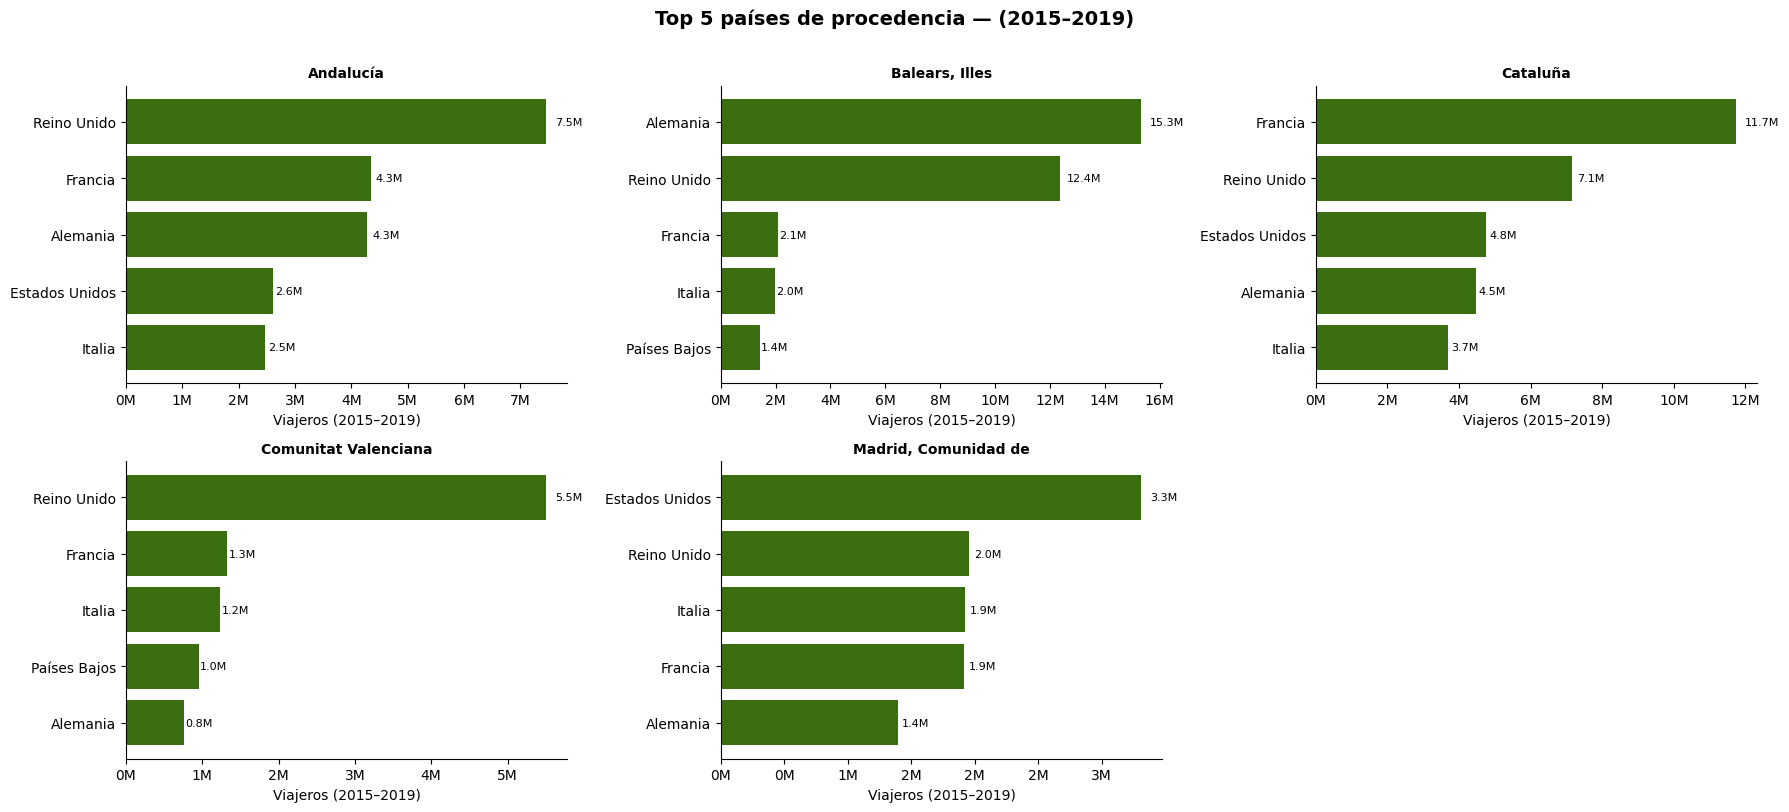

In [11]:
# ── VISUALIZACIÓN ──────────────────────────────────────────────────

ccaas = sorted(df_top_filtrado["CCAA"].unique())
n_cols = 3
n_rows = -(-len(ccaas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, ccaa in enumerate(ccaas):
    ax = axes[i]
    
    datos = (
        df_top_filtrado[df_top_filtrado["CCAA"] == ccaa]
        .sort_values("Total", ascending=True)
    )
    
    bars = ax.barh(datos["País de residencia"], datos["Total"], color="#3B6D11")
    
    for bar, val in zip(bars, datos["Total"]):
        ax.text(
            bar.get_width() * 1.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=8
        )
    
    ax.set_title(ccaa, fontweight="bold", fontsize=10)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Viajeros (2015–2019)")

# eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Top 5 países de procedencia — (2015–2019)",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.savefig("procedencia_ccaa_seleccionadas.png", dpi=150, bbox_inches="tight")
plt.show()